In [5]:
#DESCRIPCIÓN: random forest baseline ( se van cambiando los parámetros para ver la optimizacion que quieras)
# Librerías:
import pandas as pd
import numpy as np
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ruta:
ruta = r"C:\Users\guill\TFG\BASESDEDATOS\MissForest\todos"

# Archivos:
archivos = [
    "AUSTRALIAModBC1.xlsx",
    "AUSTRALIAModSB1_LIMPIO.xlsx",
    "AustraliaModSC1.xlsx",

    "CANADAModBC1.xlsx",
    "CANADAModSB1_LIMPIO.xlsx",
    "CANADAModSC1.xlsx",

    "EUROPEModBC1.xlsx",
    "EUROPEModSB1.xlsx",
    "EUROPEModSC1.xlsx",

    "JAPANModBC1.xlsx",
    "JAPANModSB1.xlsx",
    "JAPANModSC1.xlsx",

    "UKModBC1.xlsx",
    "UKModSB1.xlsx",
    "UKModSC1.xlsx",

    "USAModBC1.xlsx",
    "USAModSB1.xlsx",
    "USAModSC1.xlsx"
]

# Se crea la variable donde se almacenan los resultados:
resultados = []

# Bucle sobre las 18 bases:
for archivo in archivos:

    print(f"Procesando: {archivo}")

    # ruta completa
    path = os.path.join(ruta, archivo)

    # leer excel
    df = pd.read_excel(path)

    # busca la palabra Rendimiento para poner esa columna como variable objetivo
    columnas_objetivo = [
        col for col in df.columns
        if "Rendimiento" in col
    ]

    if len(columnas_objetivo) == 0:
        print(f"No se encontró variable objetivo en {archivo}")
        continue

    objetivo = columnas_objetivo[0]

    # Eliminar filas sin variable objetivo
    df = df.dropna(subset=[objetivo])

    # Separar X e Y
    y = df[objetivo]
    X = df.drop(columns=[objetivo])

    # Eliminar fecha:
    columnas_fecha = [
        col for col in X.columns
        if "fecha" in col.lower()
    ]

    X = X.drop(columns=columnas_fecha, errors="ignore")

    # Solo variables numéricas
    X = X.select_dtypes(include=[np.number])

    # Eliminar columnas totalmente vacías
    X = X.dropna(axis=1, how="all")

    # Rellenar valores faltantes restantes con la mediana
    X = X.fillna(X.median())

    # Separar entrenamiento y test respetando el orden temporal
    corte = int(len(df) * 0.8)

    X_train = X.iloc[:corte]
    X_test = X.iloc[corte:]

    y_train = y.iloc[:corte]
    y_test = y.iloc[corte:]

    # Aplicar Random Forest: LOS PARÁMETROS SE VAN CAMBIANDO 
    modelo = RandomForestRegressor(
        n_estimators=300,
        bootstrap=True,
        max_features=1,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    )

    # Entrenar modelo
    modelo.fit(X_train, y_train)

    # Predicciones
    y_pred = modelo.predict(X_test)

    # Sacar errores
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    oob = modelo.oob_score_

    # Guardar resultados
    resultados.append({
        "Base": archivo,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "OOB": oob
    })

# Tabla final:
tabla_resultados = pd.DataFrame(resultados)

print("\nRESULTADOS RANDOM FOREST BASELINE\n")
print(tabla_resultados)

Procesando: AUSTRALIAModBC1.xlsx
Procesando: AUSTRALIAModSB1_LIMPIO.xlsx
Procesando: AustraliaModSC1.xlsx
Procesando: CANADAModBC1.xlsx
Procesando: CANADAModSB1_LIMPIO.xlsx
Procesando: CANADAModSC1.xlsx
Procesando: EUROPEModBC1.xlsx
Procesando: EUROPEModSB1.xlsx
Procesando: EUROPEModSC1.xlsx
Procesando: JAPANModBC1.xlsx
Procesando: JAPANModSB1.xlsx
Procesando: JAPANModSC1.xlsx
Procesando: UKModBC1.xlsx
Procesando: UKModSB1.xlsx
Procesando: UKModSC1.xlsx
Procesando: USAModBC1.xlsx
Procesando: USAModSB1.xlsx
Procesando: USAModSC1.xlsx

RESULTADOS RANDOM FOREST BASELINE

                           Base      RMSE       MAE        R2       OOB
0          AUSTRALIAModBC1.xlsx  0.016497  0.011730  0.110895  0.249278
1   AUSTRALIAModSB1_LIMPIO.xlsx  0.036810  0.027797  0.158277  0.146693
2          AustraliaModSC1.xlsx  0.035920  0.027127  0.117509  0.254540
3             CANADAModBC1.xlsx  0.015784  0.011579  0.081277  0.254302
4      CANADAModSB1_LIMPIO.xlsx  0.033595  0.025303  0.168375  0.

In [6]:
# PROMEDIO: (se ejcuta depsues para ver optimizacion en conjunto)

promedios = tabla_resultados[["RMSE", "MAE", "R2", "OOB"]].mean()

print("\nPROMEDIO TOTAL DE LAS 18 BASES\n")
print(promedios)


PROMEDIO TOTAL DE LAS 18 BASES

RMSE    0.031218
MAE     0.023710
R2      0.103724
OOB     0.194140
dtype: float64


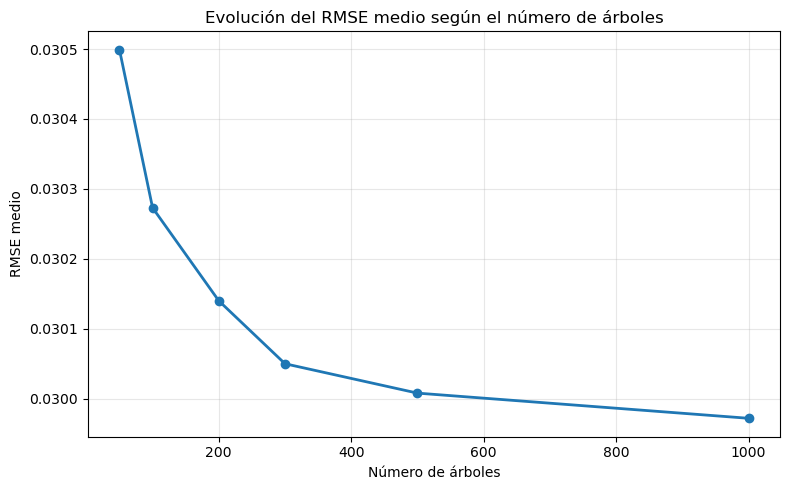

In [29]:
#DESCRIPCIÓN: a partir de aquí se hacen los gráficos de los 8 errores (4 por cada parámetro)
import matplotlib.pyplot as plt

# valores
n_arboles = [50, 100, 200, 300, 500, 1000]

rmse = [
    0.030499,
    0.030273,
    0.030140,
    0.030050,
    0.030008,
    0.029972
]

# gráfico
plt.figure(figsize=(8,5))

plt.plot(
    n_arboles,
    rmse,
    marker='o',
    linewidth=2
)

plt.xlabel("Número de árboles")
plt.ylabel("RMSE medio")
plt.title("Evolución del RMSE medio según el número de árboles")

plt.grid(alpha=0.3)

plt.tight_layout()

# GUARDAR IMAGEN
plt.savefig(
    r"C:\Users\guill\TFG\rmse_n_estimators.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

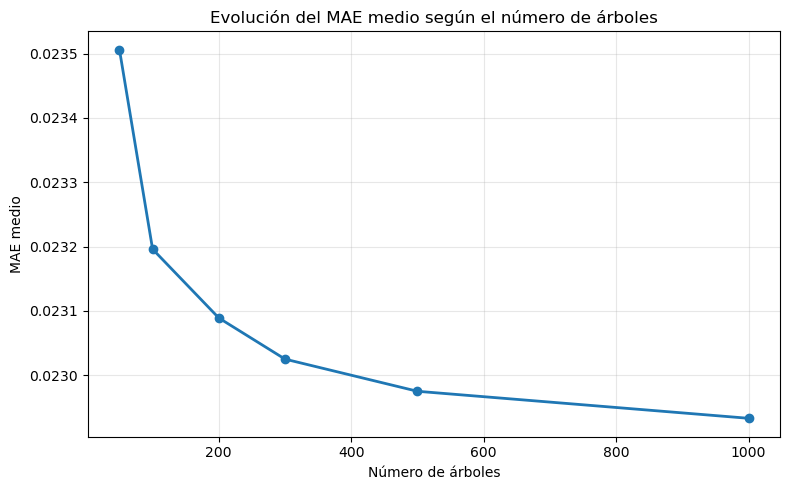

In [1]:
import matplotlib.pyplot as plt

# valores
n_arboles = [50, 100, 200, 300, 500, 1000]

mae = [
    0.023506,
    0.023196,
    0.023089,
    0.023025,
    0.022975,
    0.022933
]

# gráfico
plt.figure(figsize=(8,5))

plt.plot(
    n_arboles,
    mae,
    marker='o',
    linewidth=2
)

plt.xlabel("Número de árboles")
plt.ylabel("MAE medio")
plt.title("Evolución del MAE medio según el número de árboles")

plt.grid(alpha=0.3)

plt.tight_layout()

# GUARDAR IMAGEN
plt.savefig(
    r"C:\Users\guill\TFG\mae_n_estimators.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

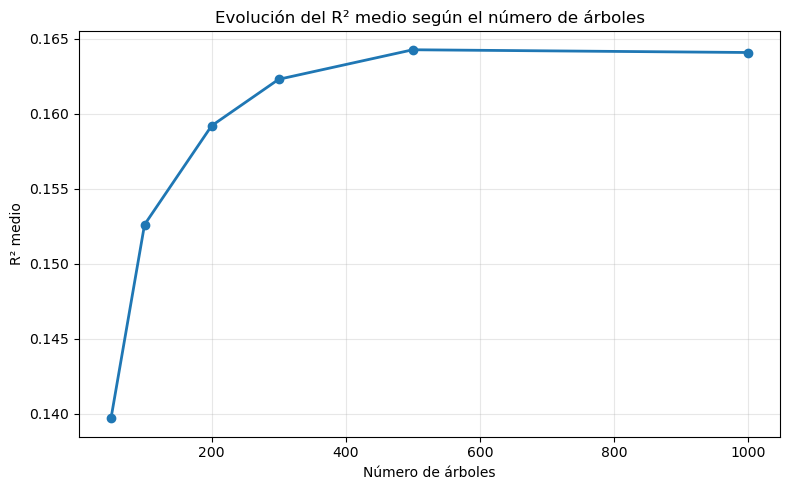

In [3]:
import matplotlib.pyplot as plt

# valores
n_arboles = [50, 100, 200, 300, 500, 1000]

r2 = [
    0.139689,
    0.152609,
    0.159203,
    0.162305,
    0.164276,
    0.164093
]

# gráfico
plt.figure(figsize=(8,5))

plt.plot(
    n_arboles,
    r2,
    marker='o',
    linewidth=2
)

plt.xlabel("Número de árboles")
plt.ylabel("R² medio")
plt.title("Evolución del R² medio según el número de árboles")

plt.grid(alpha=0.3)

plt.tight_layout()

# GUARDAR IMAGEN
plt.savefig(
    r"C:\Users\guill\TFG\r2_n_estimators.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

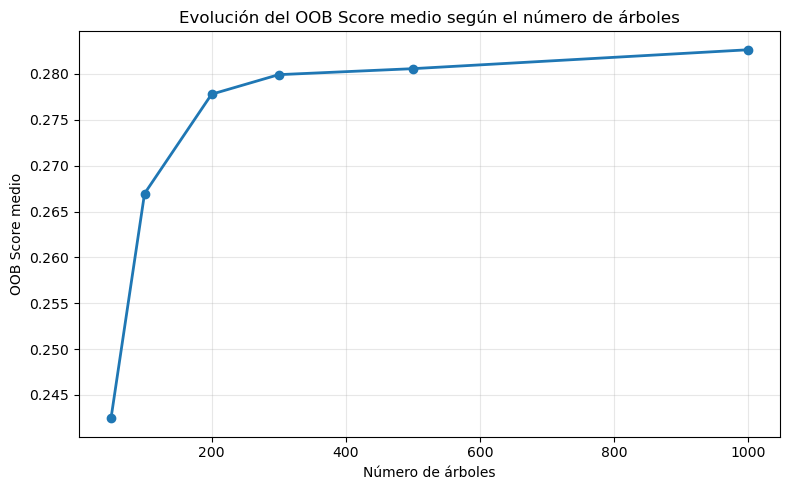

In [5]:
import matplotlib.pyplot as plt

# valores
n_arboles = [50, 100, 200, 300, 500, 1000]

oob_score = [
    0.242446,
    0.266956,
    0.277792,
    0.279925,
    0.280579,
    0.282641
]

# gráfico
plt.figure(figsize=(8,5))

plt.plot(
    n_arboles,
    oob_score,
    marker='o',
    linewidth=2
)

plt.xlabel("Número de árboles")
plt.ylabel("OOB Score medio")
plt.title("Evolución del OOB Score medio según el número de árboles")

plt.grid(alpha=0.3)

plt.tight_layout()

# GUARDAR IMAGEN
plt.savefig(
    r"C:\Users\guill\TFG\oob_score_n_estimators.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

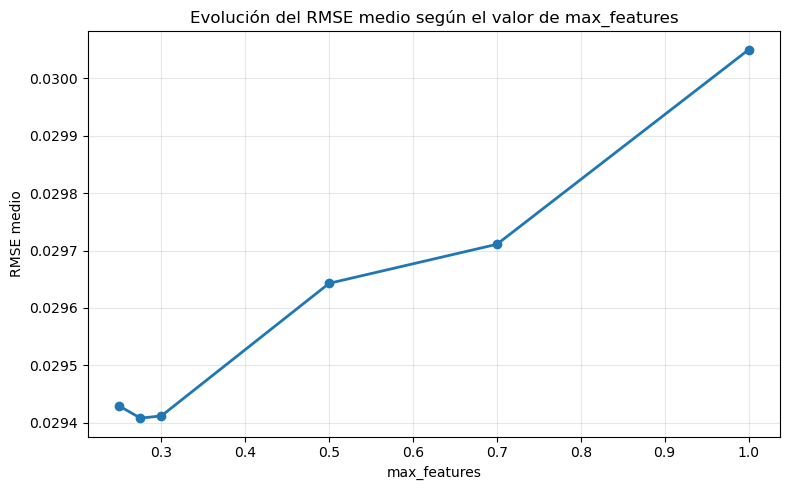

In [6]:
import matplotlib.pyplot as plt

# valores del parámetro
max_features = [
    0.25,
    0.275,
    0.30,
    0.50,
    0.70,
    1.00
]

# RMSE medio correspondiente
rmse = [
    0.029429,
    0.029408,
    0.029412,
    0.029643,
    0.029711,
    0.030050
]

# gráfico
plt.figure(figsize=(8,5))

plt.plot(
    max_features,
    rmse,
    marker='o',
    linewidth=2
)

plt.xlabel("max_features")
plt.ylabel("RMSE medio")
plt.title("Evolución del RMSE medio según el valor de max_features")

plt.grid(alpha=0.3)

plt.tight_layout()

# guardar imagen
plt.savefig(
    r"C:\Users\guill\TFG\rmse_max_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

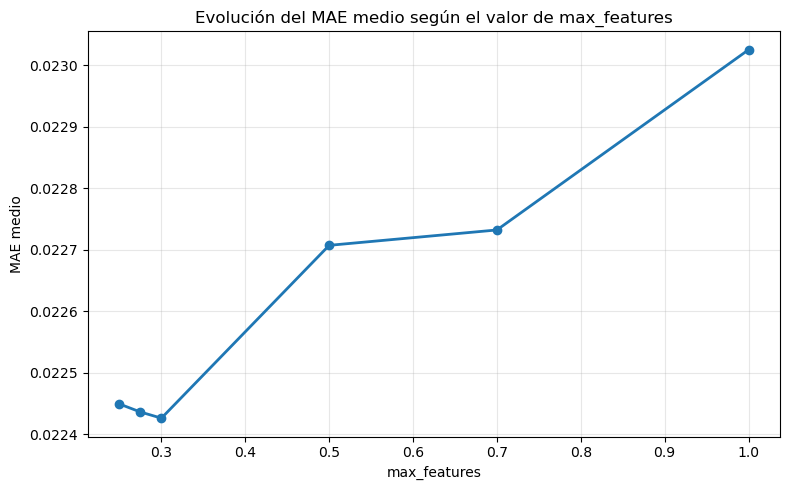

In [9]:
import matplotlib.pyplot as plt

# valores del parámetro
max_features = [
    0.25,
    0.275,
    0.30,
    0.50,
    0.70,
    1.00
]

# MAE medio correspondiente
mae = [
    0.022449,
    0.022436,
    0.022426,
    0.022707,
    0.022732,
    0.023025
]

# gráfico
plt.figure(figsize=(8,5))

plt.plot(
    max_features,
    mae,
    marker='o',
    linewidth=2
)

plt.xlabel("max_features")
plt.ylabel("MAE medio")
plt.title("Evolución del MAE medio según el valor de max_features")

plt.grid(alpha=0.3)

plt.tight_layout()

# guardar imagen
plt.savefig(
    r"C:\Users\guill\TFG\mae_max_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

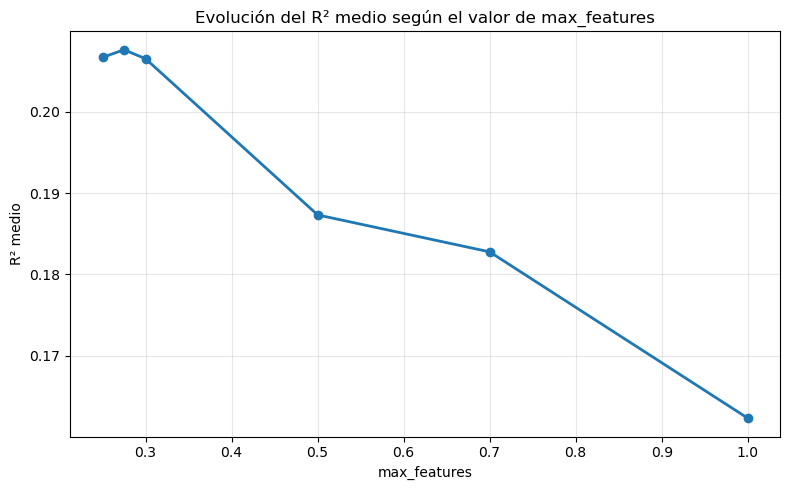

In [11]:
import matplotlib.pyplot as plt

# valores del parámetro
max_features = [
    0.25,
    0.275,
    0.30,
    0.50,
    0.70,
    1.00
]

# R² medio correspondiente
r2 = [
    0.206714,
    0.207649,
    0.206546,
    0.187322,
    0.182772,
    0.162305
]

# gráfico
plt.figure(figsize=(8,5))

plt.plot(
    max_features,
    r2,
    marker='o',
    linewidth=2
)

plt.xlabel("max_features")
plt.ylabel("R² medio")
plt.title("Evolución del R² medio según el valor de max_features")

plt.grid(alpha=0.3)

plt.tight_layout()

# guardar imagen
plt.savefig(
    r"C:\Users\guill\TFG\r2_max_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

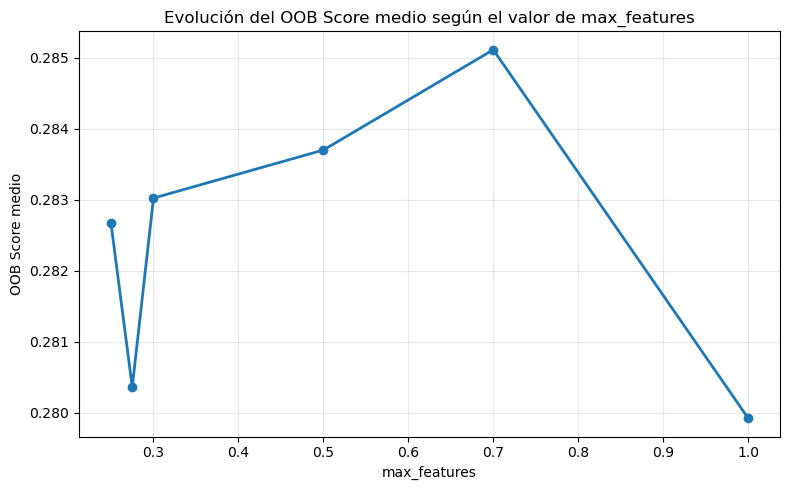

In [13]:
import matplotlib.pyplot as plt

# valores del parámetro
max_features = [
    0.25,
    0.275,
    0.30,
    0.50,
    0.70,
    1.00
]

# OOB Score medio correspondiente
oob_score = [
    0.282667,
    0.280362,
    0.283024,
    0.283701,
    0.285113,
    0.279925
]

# gráfico
plt.figure(figsize=(8,5))

plt.plot(
    max_features,
    oob_score,
    marker='o',
    linewidth=2
)

plt.xlabel("max_features")
plt.ylabel("OOB Score medio")
plt.title("Evolución del OOB Score medio según el valor de max_features")

plt.grid(alpha=0.3)

plt.tight_layout()

# guardar imagen
plt.savefig(
    r"C:\Users\guill\TFG\oob_score_max_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
#DESCRIPCIÓN: MODELO ROLLING WINDOW...como el tiempo de ejecución es altisimo se hace base a base
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==================================================
# CARGAR BASE
# ==================================================

ruta = r"C:\Users\guill\TFG\BASESDEDATOS\MissForest\todos\USAModBC1.xlsx" #Esto se cambia cada vez que estudies una bse de datos

df = pd.read_excel(ruta)

objetivo = [col for col in df.columns if "Rendimiento" in col][0]

df = df.dropna(subset=[objetivo])

y = df[objetivo]

X = df.drop(columns=[objetivo])

X = X.drop(columns=["Fecha"], errors="ignore")
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())

# ==================================================
# PARÁMETROS
# ==================================================

ventana = 120
paso = 1

predicciones = []
reales = []

total_iteraciones = len(range(ventana, len(df), paso))

print(f"Total iteraciones: {total_iteraciones}\n")

# ==================================================
# ROLLING WINDOW
# ==================================================

for n_iter, i in enumerate(range(ventana, len(df), paso), start=1):

    print(f"Iteración {n_iter} de {total_iteraciones}")

    X_train = X.iloc[i-ventana:i]
    y_train = y.iloc[i-ventana:i]

    X_test = X.iloc[[i]]
    y_test = y.iloc[i]
#Estos paráemtros también se pueden cambiar
    modelo = RandomForestRegressor(
        n_estimators=300,
        max_features=0.275,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)[0]

    predicciones.append(pred)
    reales.append(y_test)

# ==================================================
# RESULTADOS
# ==================================================

rmse = np.sqrt(mean_squared_error(reales, predicciones))
mae = mean_absolute_error(reales, predicciones)
r2 = r2_score(reales, predicciones)

print("\nRESULTADOS FINALES\n")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

Total iteraciones: 792

Iteración 1 de 792
Iteración 2 de 792
Iteración 3 de 792
Iteración 4 de 792
Iteración 5 de 792
Iteración 6 de 792
Iteración 7 de 792
Iteración 8 de 792
Iteración 9 de 792
Iteración 10 de 792
Iteración 11 de 792
Iteración 12 de 792
Iteración 13 de 792
Iteración 14 de 792
Iteración 15 de 792
Iteración 16 de 792
Iteración 17 de 792
Iteración 18 de 792
Iteración 19 de 792
Iteración 20 de 792
Iteración 21 de 792
Iteración 22 de 792
Iteración 23 de 792
Iteración 24 de 792
Iteración 25 de 792
Iteración 26 de 792
Iteración 27 de 792
Iteración 28 de 792
Iteración 29 de 792
Iteración 30 de 792
Iteración 31 de 792
Iteración 32 de 792
Iteración 33 de 792
Iteración 34 de 792
Iteración 35 de 792
Iteración 36 de 792
Iteración 37 de 792
Iteración 38 de 792
Iteración 39 de 792
Iteración 40 de 792
Iteración 41 de 792
Iteración 42 de 792
Iteración 43 de 792
Iteración 44 de 792
Iteración 45 de 792
Iteración 46 de 792
Iteración 47 de 792
Iteración 48 de 792
Iteración 49 de 792
Itera

In [66]:
#DESCRIPCIÓN: otra vez rolling window pero con otra base( iba ejecutando de dos en dos)
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==================================================
# CARGAR BASE
# ==================================================

ruta = r"C:\Users\guill\TFG\BASESDEDATOS\MissForest\todos\AUSTRALIAModSB1_LIMPIO.xlsx"

df = pd.read_excel(ruta)

objetivo = [col for col in df.columns if "Rendimiento" in col][0]

df = df.dropna(subset=[objetivo])

y = df[objetivo]

X = df.drop(columns=[objetivo])

X = X.drop(columns=["Fecha"], errors="ignore")
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())

# ==================================================
# PARÁMETROS
# ==================================================

ventana = 120
paso = 1

predicciones = []
reales = []

total_iteraciones = len(range(ventana, len(df), paso))

print(f"Total iteraciones: {total_iteraciones}\n")

# ==================================================
# ROLLING WINDOW
# ==================================================

for n_iter, i in enumerate(range(ventana, len(df), paso), start=1):

    print(f"Iteración {n_iter} de {total_iteraciones}")

    X_train = X.iloc[i-ventana:i]
    y_train = y.iloc[i-ventana:i]

    X_test = X.iloc[[i]]
    y_test = y.iloc[i]

    modelo = RandomForestRegressor(
        n_estimators=300,
        max_features=0.275,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)[0]

    predicciones.append(pred)
    reales.append(y_test)

# ==================================================
# RESULTADOS
# ==================================================

rmse = np.sqrt(mean_squared_error(reales, predicciones))
mae = mean_absolute_error(reales, predicciones)
r2 = r2_score(reales, predicciones)

print("\nRESULTADOS FINALES\n")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)



Total iteraciones: 792

Iteración 1 de 792
Iteración 2 de 792
Iteración 3 de 792
Iteración 4 de 792
Iteración 5 de 792
Iteración 6 de 792
Iteración 7 de 792
Iteración 8 de 792
Iteración 9 de 792
Iteración 10 de 792
Iteración 11 de 792
Iteración 12 de 792
Iteración 13 de 792
Iteración 14 de 792
Iteración 15 de 792
Iteración 16 de 792
Iteración 17 de 792
Iteración 18 de 792
Iteración 19 de 792
Iteración 20 de 792
Iteración 21 de 792
Iteración 22 de 792
Iteración 23 de 792
Iteración 24 de 792
Iteración 25 de 792
Iteración 26 de 792
Iteración 27 de 792
Iteración 28 de 792
Iteración 29 de 792
Iteración 30 de 792
Iteración 31 de 792
Iteración 32 de 792
Iteración 33 de 792
Iteración 34 de 792
Iteración 35 de 792
Iteración 36 de 792
Iteración 37 de 792
Iteración 38 de 792
Iteración 39 de 792
Iteración 40 de 792
Iteración 41 de 792
Iteración 42 de 792
Iteración 43 de 792
Iteración 44 de 792
Iteración 45 de 792
Iteración 46 de 792
Iteración 47 de 792
Iteración 48 de 792
Iteración 49 de 792
Itera

In [68]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==================================================
# CARGAR BASE
# ==================================================

ruta = r"C:\Users\guill\TFG\BASESDEDATOS\MissForest\todos\AustraliaModSC1.xlsx"

df = pd.read_excel(ruta)

objetivo = [col for col in df.columns if "Rendimiento" in col][0]

df = df.dropna(subset=[objetivo])

y = df[objetivo]

X = df.drop(columns=[objetivo])

X = X.drop(columns=["Fecha"], errors="ignore")
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())

# ==================================================
# PARÁMETROS
# ==================================================

ventana = 120
paso = 1

predicciones = []
reales = []

total_iteraciones = len(range(ventana, len(df), paso))

print(f"Total iteraciones: {total_iteraciones}\n")

# ==================================================
# ROLLING WINDOW
# ==================================================

for n_iter, i in enumerate(range(ventana, len(df), paso), start=1):

    print(f"Iteración {n_iter} de {total_iteraciones}")

    X_train = X.iloc[i-ventana:i]
    y_train = y.iloc[i-ventana:i]

    X_test = X.iloc[[i]]
    y_test = y.iloc[i]

    modelo = RandomForestRegressor(
        n_estimators=300,
        max_features=0.275,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)[0]

    predicciones.append(pred)
    reales.append(y_test)

# ==================================================
# RESULTADOS
# ==================================================

rmse = np.sqrt(mean_squared_error(reales, predicciones))
mae = mean_absolute_error(reales, predicciones)
r2 = r2_score(reales, predicciones)

print("\nRESULTADOS FINALES\n")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Total iteraciones: 792

Iteración 1 de 792
Iteración 2 de 792
Iteración 3 de 792
Iteración 4 de 792
Iteración 5 de 792
Iteración 6 de 792
Iteración 7 de 792
Iteración 8 de 792
Iteración 9 de 792
Iteración 10 de 792
Iteración 11 de 792
Iteración 12 de 792
Iteración 13 de 792
Iteración 14 de 792
Iteración 15 de 792
Iteración 16 de 792
Iteración 17 de 792
Iteración 18 de 792
Iteración 19 de 792
Iteración 20 de 792
Iteración 21 de 792
Iteración 22 de 792
Iteración 23 de 792
Iteración 24 de 792
Iteración 25 de 792
Iteración 26 de 792
Iteración 27 de 792
Iteración 28 de 792
Iteración 29 de 792
Iteración 30 de 792
Iteración 31 de 792
Iteración 32 de 792
Iteración 33 de 792
Iteración 34 de 792
Iteración 35 de 792
Iteración 36 de 792
Iteración 37 de 792
Iteración 38 de 792
Iteración 39 de 792
Iteración 40 de 792
Iteración 41 de 792
Iteración 42 de 792
Iteración 43 de 792
Iteración 44 de 792
Iteración 45 de 792
Iteración 46 de 792
Iteración 47 de 792
Iteración 48 de 792
Iteración 49 de 792
Itera